In [7]:
import os
os.listdir()


['.config', 'Sales_data.csv', '.ipynb_checkpoints', 'sample_data']

In [8]:
import pandas as pd

df = pd.read_csv('Sales_data.csv')
df.head()

,order_id,product,region,amount,date
0,1,Laptop,US,1200,2024-01-10
1,2,Phone,India,800,2024-01-12
2,3,Tablet,US,400,2024-01-15
3,4,Laptop,UK,1300,2024-02-10
4,5,Phone,US,900,2024-02-18


In [9]:
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   order_id  5 non-null      int64 
 1   product   5 non-null      object
 2   region    5 non-null      object
 3   amount    5 non-null      int64 
 4   date      5 non-null      object
dtypes: int64(2), object(3)
memory usage: 332.0+ bytes


In [10]:
df = df.dropna()
df['amount'] = df['amount'].astype(float)

In [11]:
print("Total Sales:", df['amount'].sum())

Total Sales: 4600.0


In [12]:
print(df.groupby('region')['amount'].sum())

region
India     800.0
UK       1300.0
US       2500.0
Name: amount, dtype: float64


In [13]:
print(df.groupby('product')['amount'].sum().sort_values(ascending=False))

product
Laptop    2500.0
Phone     1700.0
Tablet     400.0
Name: amount, dtype: float64


In [14]:
region_sales = df.groupby('region')['amount'].sum()
product_sales = df.groupby('product')['amount'].sum().sort_values(ascending=False)

print("Region Sales:\n", region_sales)
print("\nTop Products:\n", product_sales)

Region Sales:
 region
India     800.0
UK       1300.0
US       2500.0
Name: amount, dtype: float64

Top Products:
 product
Laptop    2500.0
Phone     1700.0
Tablet     400.0
Name: amount, dtype: float64


In [15]:
import matplotlib.pyplot as plt

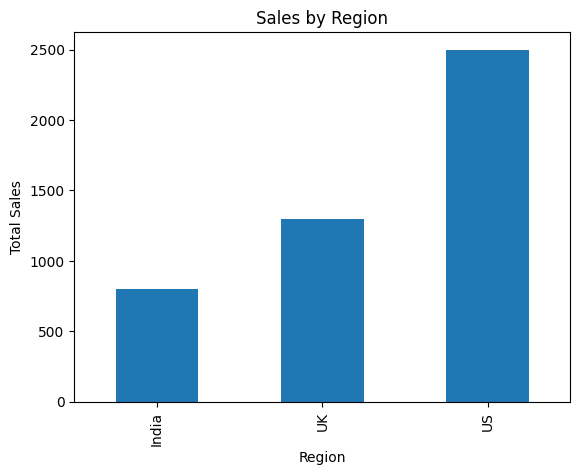

In [16]:
region_sales = df.groupby('region')['amount'].sum()

region_sales.plot(kind='bar')
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.show()

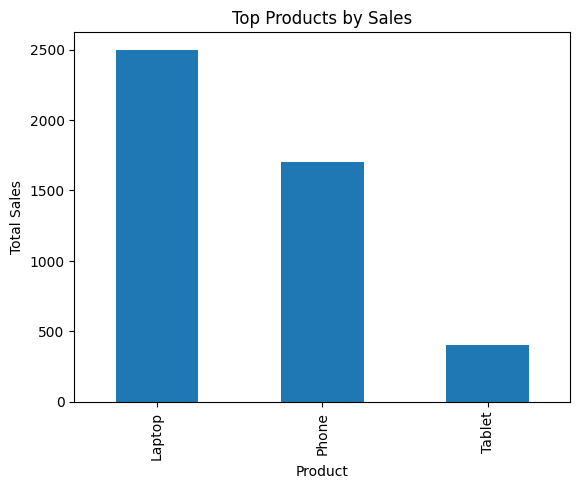

In [17]:
product_sales = df.groupby('product')['amount'].sum().sort_values(ascending=False)

product_sales.plot(kind='bar')
plt.title("Top Products by Sales")
plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.show()

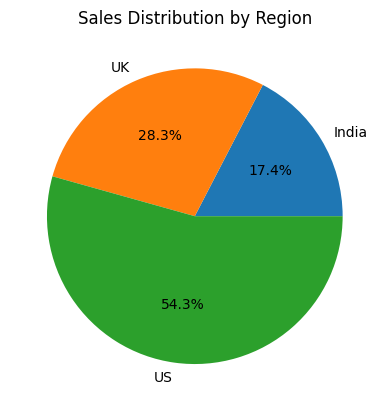

In [18]:
region_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title("Sales Distribution by Region")
plt.ylabel("")
plt.show()

In [19]:
print("Missing Values:\n", df.isnull().sum())
print("\nData Types:\n", df.dtypes)

Missing Values:
 order_id    0
product     0
region      0
amount      0
date        0
dtype: int64

Data Types:
 order_id      int64
product      object
region       object
amount      float64
date         object
dtype: object


In [20]:
max_region = df.groupby('region')['amount'].sum().idxmax()
max_product = df.groupby('product')['amount'].sum().idxmax()

print("Top Performing Region:", max_region)
print("Top Performing Product:", max_product)

Top Performing Region: US
Top Performing Product: Laptop


In [21]:
def calculate_total_sales(data):
    return data['amount'].sum()

print("Total Sales:", calculate_total_sales(df))

Total Sales: 4600.0
